In [6]:
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics.pairwise import cosine_similarity

In [7]:
df = pd.read_csv("processed_music_dataset2.csv")

kmeans = joblib.load("kmeans_model.pkl")

scaler = joblib.load("scaler.pkl")

model = load_model(
    "transformer_model.h5",
    custom_objects={"GetItem": tf.keras.layers.Layer},
    compile=False
)

In [8]:
feature_cols = [
'danceability',
'energy',
'loudness',
'speechiness',
'acousticness',
'instrumentalness',
'liveness',
'valence',
'tempo'
]

X = df[feature_cols]
X_scaled = scaler.transform(X)

In [9]:
user_sequence = [10, 25, 80, 102, 56]

In [10]:
user_mood = "Energetic"

In [11]:
seq = np.array(user_sequence).reshape(1,-1)

pred = model.predict(seq)

predicted_cluster = np.argmax(pred)

print("Predicted cluster:", predicted_cluster)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
Predicted cluster: 6


In [12]:
candidate_df = df[df['cluster'] == predicted_cluster]

candidate_indices = candidate_df.index

In [13]:
last_song = user_sequence[-1]

song_vector = X_scaled[last_song].reshape(1,-1)

cluster_vectors = X_scaled[candidate_indices]

similarity = cosine_similarity(song_vector, cluster_vectors)[0]

In [14]:
results = []

for i, sim in enumerate(similarity):

    song = candidate_df.iloc[i]

    fuzzy = 1 if song['mood'] == user_mood else 0

    transformer_score = 1

    final_score = 0.5*sim + 0.3*transformer_score + 0.2*fuzzy

    results.append((song['track_name'], song['artists'], final_score))

In [15]:
results = sorted(results, key=lambda x: x[2], reverse=True)

top_recommendations = results[:10]

In [16]:
print("Recommended Songs:\n")

for r in top_recommendations:

    print(r[0], "-", r[1], "score:", round(r[2],3))

Recommended Songs:

Tere Naam - Alka Yagnik score: 0.899
April Mayilae (From "Idhayam") - Ilaiyaraaja score: 0.891
I Say A Little Prayer (Glee Cast Version) - Glee Cast score: 0.884
Thare Vaaste - Divya Kumar score: 0.879
夏天 - Nicky Lee score: 0.878
Chori Chori Chupke Chupke - Chori Chori Chupke Chupke / Soundtrack Version - Alka Yagnik;Babul Supriyo score: 0.878
Fakira - Vishal-Shekhar;Sanam Puri;Neeti Mohan score: 0.871
Tão Seu - Raça Negra score: 0.847
Un Hombre Normal - Willie Gonzalez score: 0.844
Come On, Let's Go - Ritchie Valens score: 0.843


In [17]:
cluster_id = df[df['track_name']=="Blinding Lights"]['cluster'].values[0]

df[df['cluster']==cluster_id][['track_name','artists']].head(10)

,track_name,artists
25,All I Want For Christmas Is A Real Good Tan,Chord Overstreet
30,The Haves,Eddie Vedder
32,You and Me on the Rock,Brandi Carlile;Lucius
33,"Speak Your Mind (From the Netflix Series ""We T...",Brandi Carlile
45,Sky's Still Blue,Andrew Belle
63,Heavy Heart,Gabrielle Aplin
68,Brave,Sara Bareilles
87,Boston,Augustana
88,Living in the Shadows,Matthew Perryman Jones
98,Believer (Remix),Ben Woodward


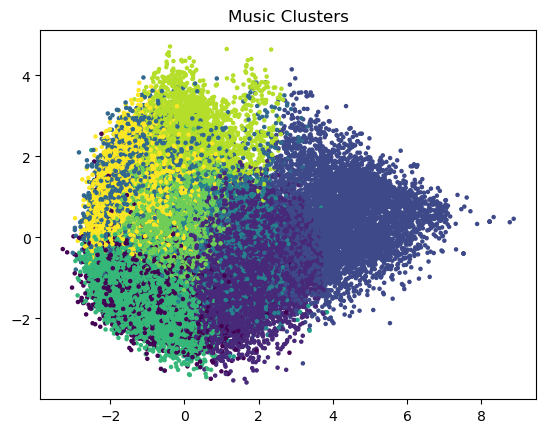

In [18]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'], s=5)

plt.title("Music Clusters")
plt.show()